In [11]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# ============================================================================
# CONFIGURATION
# ============================================================================

class Config:
   
    DATA_PATH = '../data/processed/mitral_valve_only'
    OUTPUT_PATH = '../exported_models'
    IMG_SIZE = (224, 224)
    BATCH_SIZE = 32
    EPOCHS = 40                     # Increase epochs (with early stopping)
    INITIAL_LR = 0.0001
    RANDOM_SEED = 42
    TARGET_MINORITY_RATIO = 0.8     # Increase from 0.5 to 0.8 (more minority samples)
    MERGE_GRADES = True             # NEW: merge Grade_1 and Grade_2
    MERGED_CLASS_NAMES = ['Grade_1', 'Grade_2', 'Grade_3']  # NEW: new class names
    USE_FOCAL_LOSS = True           # NEW: switch to focal loss
    FOCAL_GAMMA = 2.0               # NEW: focal loss parameter

config = Config()
os.makedirs(config.OUTPUT_PATH, exist_ok=True)


In [12]:
# ============================================================================
# DATA LOADING WITH GRADE MERGING (1 & 2 → 'Grade_1_2')
# ============================================================================


print(" LOADING AND BALANCING DATASET")


# Load full dataset
full_ds = tf.keras.preprocessing.image_dataset_from_directory(
    config.DATA_PATH,
    seed=config.RANDOM_SEED,
    image_size=config.IMG_SIZE,
    batch_size=config.BATCH_SIZE,
    label_mode='int',
    shuffle=True
)

original_class_names = full_ds.class_names
print(f"Original classes: {original_class_names}")

# --- Merge labels: 0 → 0, 1 → 1, 2 → 1, 3 → 2 (if we want Grade_0, Grade_1_2, Grade_3)
# We'll map: 0->0, 1->1, 2->1, 3->2
def merge_labels(image, label):
    # label is a scalar int
    # If label == 1 or 2, set to 1; else keep as is (0 or 3)
    # But we also need to remap 3 -> 2 so that class indices are 0,1,2
    new_label = tf.where(tf.logical_or(tf.equal(label, 1), tf.equal(label, 2)), 
                         1, label)
    # Now remap 3 -> 2 (so we have 0,1,2)
    new_label = tf.where(tf.equal(new_label, 3), 2, new_label)
    return image, new_label

# Apply merging to the full dataset
full_ds_merged = full_ds.map(merge_labels)

# Update class names and number of classes
class_names = ['Grade_0', 'Grade_1', 'Grade_2']  # new 3-class scheme
num_classes = len(class_names)
print(f"New classes after merging: {class_names}")

# --- Split into train/val/test BEFORE or AFTER merging? 
# We'll do it after merging so all splits have merged labels.
dataset_size = tf.data.experimental.cardinality(full_ds_merged).numpy()
train_size = int(0.7 * dataset_size)
val_size = int(0.15 * dataset_size)
test_size = dataset_size - train_size - val_size

train_ds = full_ds_merged.take(train_size)
remaining_ds = full_ds_merged.skip(train_size)
val_ds = remaining_ds.take(val_size)
test_ds = remaining_ds.skip(val_size)

print(f"\nDataset splits (batches): Train={train_size}, Val={val_size}, Test={test_size}")

# --- Check class distribution in training set (after merging)
print("\nClass Distribution (Before Balancing):")
labels = []
for _, y in train_ds:
    labels.extend(y.numpy().tolist())
labels = np.array(labels)

class_counts = Counter(labels)
for i, name in enumerate(class_names):
    count = class_counts.get(i, 0)
    print(f"  {name}: {count} ({count/len(labels)*100:.1f}%)")

 LOADING AND BALANCING DATASET
Found 16451 files belonging to 4 classes.
Original classes: ['Grade_0', 'Grade_1', 'Grade_2', 'Grade_3']
New classes after merging: ['Grade_0', 'Grade_1', 'Grade_2']

Dataset splits (batches): Train=360, Val=77, Test=78

Class Distribution (Before Balancing):
  Grade_0: 9012 (78.2%)
  Grade_1: 1777 (15.4%)
  Grade_2: 731 (6.3%)


2026-06-22 15:42:45.447013: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [13]:

# ============================================================================
# SAMPLING STRATEGY
# ============================================================================

print("\n🔄 Applying Sampling Strategy...")

def balance_dataset(dataset, class_names, target_ratio=0.5):
    """Oversample minority classes to reach target ratio."""
    
    # Extract all data
    images = []
    labels = []
    
    for img_batch, label_batch in dataset:
        images.extend(img_batch.numpy())
        labels.extend(label_batch.numpy())
    
    images = np.array(images)
    labels = np.array(labels)
    
    # Calculate target samples
    majority_count = max(Counter(labels).values())
    target_samples = {}
    
    for class_id in np.unique(labels):
        if class_id == 0:  # Majority class
            target_samples[class_id] = majority_count
        else:
            target_samples[class_id] = int(majority_count * target_ratio)
    
    # Resample
    balanced_images = []
    balanced_labels = []
    
    for class_id in np.unique(labels):
        class_mask = labels == class_id
        class_images = images[class_mask]
        class_labels = labels[class_mask]
        n_samples = target_samples[class_id]
        
        if len(class_images) == 0:
            continue
            
        if len(class_images) < n_samples:
            # Oversample with replacement
            indices = np.random.choice(len(class_images), n_samples, replace=True)
        else:
            # Undersample without replacement
            indices = np.random.choice(len(class_images), n_samples, replace=False)
            
        balanced_images.extend(class_images[indices])
        balanced_labels.extend(class_labels[indices])
    
    return np.array(balanced_images), np.array(balanced_labels)

# Apply balancing
balanced_images, balanced_labels = balance_dataset(
    train_ds, class_names, config.TARGET_MINORITY_RATIO
)

print(f"\nBalanced distribution:")
for i, name in enumerate(class_names):
    count = np.sum(balanced_labels == i)
    print(f"  {name}: {count} ({count/len(balanced_labels)*100:.1f}%)")



🔄 Applying Sampling Strategy...


2026-06-22 15:42:47.246122: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



Balanced distribution:
  Grade_0: 9010 (38.5%)
  Grade_1: 7208 (30.8%)
  Grade_2: 7208 (30.8%)


In [14]:
# ============================================================================
# CREATE TENSORFLOW DATASET
# ============================================================================

def create_tf_dataset(images, labels, batch_size, shuffle=True):
    """Create TensorFlow dataset from numpy arrays."""
    dataset = tf.data.Dataset.from_tensor_slices((images, labels))
    if shuffle:
        dataset = dataset.shuffle(len(images), seed=config.RANDOM_SEED)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

train_ds_balanced = create_tf_dataset(
    balanced_images, balanced_labels, config.BATCH_SIZE, shuffle=True
)

In [15]:
# ============================================================================
# CLASS WEIGHTS
# ============================================================================

print("\n⚖️  Calculating Class Weights (Post-Sampling)...")

balanced_labels_array = balanced_labels
unique_classes = np.unique(balanced_labels_array)
weights = class_weight.compute_class_weight(
    'balanced',
    classes=unique_classes,
    y=balanced_labels_array
)

# Gentle medical boost
medical_boost = [1.0, 1.2, 1.8] 
weights = weights * medical_boost[:len(class_names)]

# Normalize
weights = weights / weights.mean() * len(class_names) / 2
class_weights = dict(enumerate(weights))

print("Class weights:")
for i, name in enumerate(class_names):
    print(f"  {name}: {weights[i]:.3f}")


⚖️  Calculating Class Weights (Post-Sampling)...
Class weights:
  Grade_0: 0.947
  Grade_1: 1.421
  Grade_2: 2.132


In [16]:
def augment_dataset(image, label):
    """Augmentation for training - Compatible version."""
    
    # Random horizontal flip (50% chance)
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
    
    # Random brightness
    image = tf.image.random_brightness(image, 0.1)
    
    # Random contrast
    image = tf.image.random_contrast(image, 0.9, 1.1)
    
    # Random saturation
    image = tf.image.random_saturation(image, 0.9, 1.1)
    
    # Random hue (small adjustment)
    image = tf.image.random_hue(image, 0.05)
    
    # Clip to valid range
    image = tf.clip_by_value(image, 0, 255)
    
    return image, label

In [17]:
# ============================================================================
# PREPARE DATASETS 
# ============================================================================

AUTOTUNE = tf.data.AUTOTUNE

# Training set with augmentation AND repeat - IMPORTANT!
train_ds_final = train_ds_balanced.repeat().map(
    augment_dataset, 
    num_parallel_calls=AUTOTUNE
)
train_ds_final = train_ds_final.prefetch(AUTOTUNE)

# Validation set with repeat
val_ds_final = val_ds.repeat().prefetch(AUTOTUNE)

# Test set (no repeat)
test_ds_final = test_ds.prefetch(AUTOTUNE)

# Calculate steps
steps_per_epoch = len(balanced_images) // config.BATCH_SIZE
validation_steps = tf.data.experimental.cardinality(val_ds).numpy()

print(f"\nSteps per epoch: {steps_per_epoch}")
print(f"Validation steps: {validation_steps}")


Steps per epoch: 732
Validation steps: 77


In [18]:
# BUILD MODEL WITH PRETRAINED MOBILENETV2

print("\n🔨 BUILDING MOBILENETV2 (TRANSFER LEARNING)")
print("="*60)

# Load base model (pretrained on ImageNet)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(*config.IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze initially

# Add custom head on top
model = models.Sequential([
    layers.Input(shape=(*config.IMG_SIZE, 3)),
    layers.Rescaling(1./127.5, offset=-1),  # MobileNetV2 expects [-1,1]
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')  # num_classes = 3
])

# Compile with focal loss if desired
if config.USE_FOCAL_LOSS:
    # Define focal loss function (as before)
    def focal_loss(gamma=2., alpha=0.25):
        def focal_loss_fixed(y_true, y_pred):
            y_true = tf.cast(y_true, tf.int32)
            y_true_one_hot = tf.one_hot(y_true, depth=num_classes)
            epsilon = tf.keras.backend.epsilon()
            y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
            cross_entropy = -y_true_one_hot * tf.math.log(y_pred)
            weight = tf.pow(1. - y_pred, gamma)
            focal = alpha * weight * cross_entropy
            return tf.reduce_sum(focal, axis=1)
        return focal_loss_fixed
    loss_fn = focal_loss(gamma=config.FOCAL_GAMMA, alpha=0.25)
else:
    loss_fn = 'sparse_categorical_crossentropy'

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=config.INITIAL_LR),
    loss=loss_fn,
    metrics=['accuracy']
)

model.summary()


🔨 BUILDING MOBILENETV2 (TRANSFER LEARNING)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,851 (9.24 MB)

 Trainable params: 164,611 (643.01 KB)

 Non-trainable params: 2,258,240 (8.61 MB)

In [19]:


# ============================================================================
# CALLBACKS
# ============================================================================

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        os.path.join(config.OUTPUT_PATH, 'models', 'best_model.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]


In [20]:

# ============================================================================
# TRAINING
# ============================================================================

print("\n" + "="*60)
print("🚀 STARTING TRAINING (Hybrid: Sampling + Weights)")
print("="*60)
print(f"Learning rate: {config.INITIAL_LR}")
print(f"Class weights: {class_weights}")
print(f"Target minority ratio: {config.TARGET_MINORITY_RATIO}")

history = model.fit(
    train_ds_final,
    validation_data=val_ds_final,
    epochs=config.EPOCHS,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)



🚀 STARTING TRAINING (Hybrid: Sampling + Weights)
Learning rate: 0.0001
Class weights: {0: 0.9473684210526316, 1: 1.4210526315789473, 2: 2.1315789473684212}
Target minority ratio: 0.8
Epoch 1/40
732/732 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.4323 - loss: 0.2898
Epoch 1: val_accuracy improved from None to 0.47930, saving model to ../exported_models/models/best_model.keras

Epoch 1: finished saving model to ../exported_models/models/best_model.keras
732/732 ━━━━━━━━━━━━━━━━━━━━ 217s 199ms/step - accuracy: 0.4554 - loss: 0.2510 - val_accuracy: 0.4793 - val_loss: 0.1295 - learning_rate: 1.0000e-04
Epoch 2/40
732/732 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.4919 - loss: 0.1957
Epoch 2: val_accuracy did not improve from 0.47930
732/732 ━━━━━━━━━━━━━━━━━━━━ 191s 261ms/step - accuracy: 0.4920 - loss: 0.1909 - val_accuracy: 0.3101 - val_loss: 0.1346 - learning_rate: 1.0000e-04
Epoch 3/40
732/732 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.5002 - loss: 0.1710
Epoch 3: val_


📊 EVALUATING ON TEST SET
78/78 ━━━━━━━━━━━━━━━━━━━━ 19s 219ms/step - accuracy: 0.5736 - loss: 0.1062

Test Accuracy: 0.5736
Test Loss: 0.1062


2026-06-22 16:17:21.365229: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



Classification Report:
              precision    recall  f1-score   support

     Grade_0     0.8954    0.6190    0.7319      1963
     Grade_1     0.2031    0.1924    0.1976       343
     Grade_2     0.1745    0.8509    0.2896       161

    accuracy                         0.5748      2467
   macro avg     0.4243    0.5541    0.4064      2467
weighted avg     0.7521    0.5748    0.6288      2467



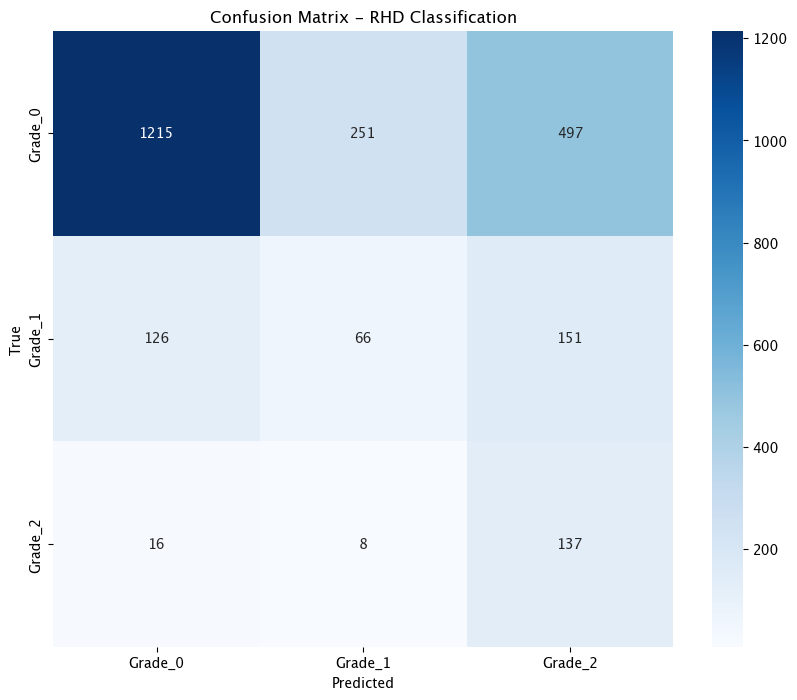

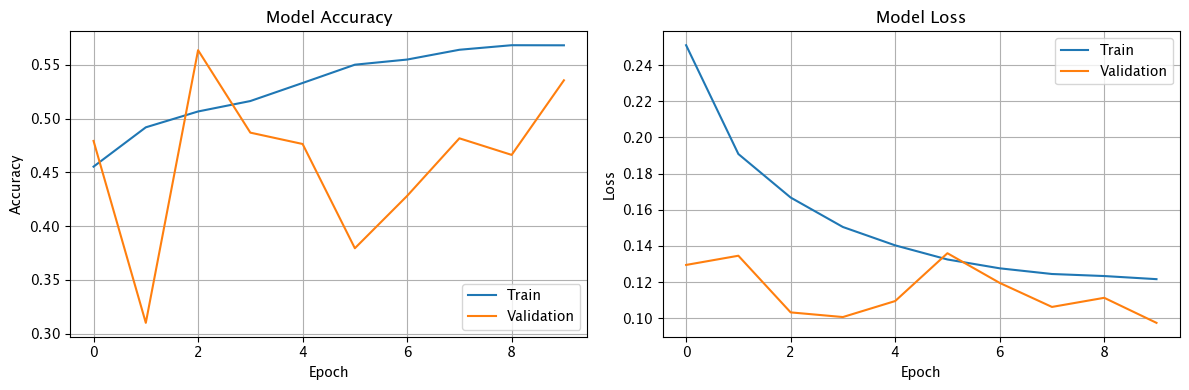


✅ Training Complete!
Best validation accuracy: 0.5637
Test accuracy: 0.5736


In [21]:

# ============================================================================
# EVALUATION
# ============================================================================

print("\n📊 EVALUATING ON TEST SET")
print("="*60)

test_loss, test_acc = model.evaluate(test_ds_final, verbose=1)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Predictions
y_true = []
y_pred = []

for images, labels in test_ds_final:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - RHD Classification')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print("\n✅ Training Complete!")
print(f"Best validation accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"Test accuracy: {test_acc:.4f}")

In [ ]:
# =============================================================================
# COMPLETE RHD TRAINING PIPELINE (EfficientNetB0 + Focal Loss + Merged Classes)
# =============================================================================

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0, MobileNetV2
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import time

# -----------------------------------------------------------------------------
# 1. CONFIGURATION – ADJUST THESE AS NEEDED
# -----------------------------------------------------------------------------
class Config:
    DATA_PATH = '../data/processed/mitral_valve_only'          # Update this
    OUTPUT_PATH = '../exported_models'                         # Update this
    IMG_SIZE = (224, 224)                                      # EfficientNet expects >= 224
    BATCH_SIZE = 32
    EPOCHS_FROZEN = 30                                         # Epochs with frozen backbone
    EPOCHS_FINETUNE = 15                                       # Fine‑tuning epochs
    INITIAL_LR = 1e-4
    FINETUNE_LR = 1e-5
    RANDOM_SEED = 42
    TARGET_MINORITY_RATIO = 0.6                                # 0.5–0.8; lower = less oversampling
    MERGE_GRADES = True                                        # Merge 1 & 2
    USE_FOCAL_LOSS = True
    FOCAL_GAMMA = 2.5                                          # >1 focuses on hard examples
    FOCAL_ALPHA = 0.15                                         # Weight for positive class; lower reduces minority bias
    MEDICAL_BOOST = [1.0, 1.2, 1.3]                            # Mild boost for abnormal classes
    USE_EFFICIENTNET = True                                    # False -> MobileNetV2
    FREEZE_LAYERS = 100                                        # Number of base layers to freeze during fine‑tune
    PATIENCE = 7                                               # Early stopping patience
    REDUCE_LR_PATIENCE = 3

config = Config()
os.makedirs(config.OUTPUT_PATH, exist_ok=True)

# -----------------------------------------------------------------------------
# 2. DATA LOADING & LABEL MERGING
# -----------------------------------------------------------------------------
print("\n" + "="*60)
print("📂 LOADING DATASET (MERGING GRADE 1 & 2)")
print("="*60)

full_ds = tf.keras.preprocessing.image_dataset_from_directory(
    config.DATA_PATH,
    seed=config.RANDOM_SEED,
    image_size=config.IMG_SIZE,
    batch_size=config.BATCH_SIZE,
    label_mode='int',
    shuffle=True
)

original_class_names = full_ds.class_names
print(f"Original classes: {original_class_names}")

# Merge labels: 0→0, 1→1, 2→1, 3→2  (so we have 3 classes: Grade_0, Grade_1_2, Grade_3)
def merge_labels(image, label):
    # label is a scalar
    new_label = tf.where(tf.logical_or(tf.equal(label, 1), tf.equal(label, 2)), 1, label)
    new_label = tf.where(tf.equal(new_label, 3), 2, new_label)
    return image, new_label

full_ds_merged = full_ds.map(merge_labels)
class_names = ['Grade_0', 'Grade_1_2', 'Grade_3']
num_classes = len(class_names)
print(f"New classes: {class_names}")

# 70/15/15 split
dataset_size = tf.data.experimental.cardinality(full_ds_merged).numpy()
train_size = int(0.7 * dataset_size)
val_size = int(0.15 * dataset_size)
test_size = dataset_size - train_size - val_size

train_ds = full_ds_merged.take(train_size)
remaining = full_ds_merged.skip(train_size)
val_ds = remaining.take(val_size)
test_ds = remaining.skip(val_size)

print(f"\nSplits (batches): Train={train_size}, Val={val_size}, Test={test_size}")

# Check distribution before balancing
labels = []
for _, y in train_ds:
    labels.extend(y.numpy().tolist())
labels = np.array(labels)
class_counts = Counter(labels)
print("\n📊 Class distribution (training set, before balancing):")
for i, name in enumerate(class_names):
    count = class_counts.get(i, 0)
    print(f"  {name}: {count} ({count/len(labels)*100:.1f}%)")

# -----------------------------------------------------------------------------
# 3. OVERSAMPLING MINORITY CLASSES
# -----------------------------------------------------------------------------
def balance_dataset(dataset, target_ratio=0.6):
    images, lbls = [], []
    for img_batch, label_batch in dataset:
        images.extend(img_batch.numpy())
        lbls.extend(label_batch.numpy())
    images = np.array(images)
    lbls = np.array(lbls)

    majority_count = max(Counter(lbls).values())
    target_samples = {}
    for cls in np.unique(lbls):
        if cls == 0:  # majority
            target_samples[cls] = majority_count
        else:
            target_samples[cls] = int(majority_count * target_ratio)

    balanced_imgs, balanced_lbls = [], []
    for cls in np.unique(lbls):
        mask = lbls == cls
        cls_imgs = images[mask]
        cls_lbls = lbls[mask]
        n = target_samples[cls]
        if len(cls_imgs) == 0:
            continue
        if len(cls_imgs) < n:
            idx = np.random.choice(len(cls_imgs), n, replace=True)
        else:
            idx = np.random.choice(len(cls_imgs), n, replace=False)
        balanced_imgs.extend(cls_imgs[idx])
        balanced_lbls.extend(cls_lbls[idx])

    return np.array(balanced_imgs), np.array(balanced_lbls)

balanced_images, balanced_labels = balance_dataset(train_ds, config.TARGET_MINORITY_RATIO)
print("\n✅ Balanced distribution:")
for i, name in enumerate(class_names):
    cnt = np.sum(balanced_labels == i)
    print(f"  {name}: {cnt} ({cnt/len(balanced_labels)*100:.1f}%)")

# Create TF dataset from balanced numpy arrays
def create_tf_dataset(images, labels, batch_size, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((images, labels))
    if shuffle:
        ds = ds.shuffle(len(images), seed=config.RANDOM_SEED)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_balanced_ds = create_tf_dataset(balanced_images, balanced_labels, config.BATCH_SIZE)

# -----------------------------------------------------------------------------
# 4. CLASS WEIGHTS (Optional – used if focal loss is disabled)
# -----------------------------------------------------------------------------
if not config.USE_FOCAL_LOSS:
    weights = class_weight.compute_class_weight('balanced',
                                                classes=np.unique(balanced_labels),
                                                y=balanced_labels)
    weights = weights * config.MEDICAL_BOOST
    weights = weights / weights.mean() * len(weights) / 2
    class_weights = dict(enumerate(weights))
else:
    class_weights = None

# -----------------------------------------------------------------------------
# 5. DATA AUGMENTATION
# -----------------------------------------------------------------------------
def augment_dataset(image, label):
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
    image = tf.image.random_brightness(image, 0.1)
    image = tf.image.random_contrast(image, 0.9, 1.1)
    image = tf.image.random_saturation(image, 0.9, 1.1)
    image = tf.image.random_hue(image, 0.05)
    image = tf.clip_by_value(image, 0, 255)
    return image, label

AUTOTUNE = tf.data.AUTOTUNE
train_ds_final = train_balanced_ds.repeat().map(augment_dataset, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds_final = val_ds.repeat().prefetch(AUTOTUNE)
test_ds_final = test_ds.prefetch(AUTOTUNE)

steps_per_epoch = len(balanced_images) // config.BATCH_SIZE
validation_steps = tf.data.experimental.cardinality(val_ds).numpy()
print(f"\nSteps per epoch: {steps_per_epoch}, Validation steps: {validation_steps}")

# -----------------------------------------------------------------------------
# 6. FOCAL LOSS DEFINITION
# -----------------------------------------------------------------------------
def focal_loss(gamma=2., alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_true_one_hot = tf.one_hot(y_true, depth=num_classes)
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
        cross_entropy = -y_true_one_hot * tf.math.log(y_pred)
        weight = tf.pow(1. - y_pred, gamma)
        focal = alpha * weight * cross_entropy
        return tf.reduce_sum(focal, axis=1)
    return focal_loss_fixed

# -----------------------------------------------------------------------------
# 7. BUILD PRETRAINED MODEL (EfficientNetB0 or MobileNetV2)
# -----------------------------------------------------------------------------
print("\n🔨 BUILDING MODEL")
print("="*60)

if config.USE_EFFICIENTNET:
    base_model = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=(*config.IMG_SIZE, 3)
    )
    print("Using EfficientNetB0 as backbone")
else:
    base_model = MobileNetV2(
        include_top=False,
        weights='imagenet',
        input_shape=(*config.IMG_SIZE, 3)
    )
    print("Using MobileNetV2 as backbone")

base_model.trainable = False

model = models.Sequential([
    layers.Input(shape=(*config.IMG_SIZE, 3)),
    layers.Rescaling(1./127.5, offset=-1),  # for EfficientNet/MobileNet
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

# Compile with focal loss or cross‑entropy
if config.USE_FOCAL_LOSS:
    loss_fn = focal_loss(gamma=config.FOCAL_GAMMA, alpha=config.FOCAL_ALPHA)
else:
    loss_fn = 'sparse_categorical_crossentropy'

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=config.INITIAL_LR),
    loss=loss_fn,
    metrics=['accuracy']
)

model.summary()

# -----------------------------------------------------------------------------
# 8. CALLBACKS
# -----------------------------------------------------------------------------
checkpoint_path = os.path.join(config.OUTPUT_PATH, 'models', 'best_model.keras')
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=config.PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=config.REDUCE_LR_PATIENCE,
        min_lr=1e-7,
        verbose=1
    )
]

# -----------------------------------------------------------------------------
# 9. PHASE 1: TRAIN WITH FROZEN BACKBONE
# -----------------------------------------------------------------------------
print("\n" + "="*60)
print("🚀 PHASE 1: TRAINING WITH FROZEN BACKBONE")
print("="*60)
print(f"Learning rate: {config.INITIAL_LR}")
if class_weights:
    print(f"Class weights: {class_weights}")
else:
    print("Using Focal Loss (alpha={}, gamma={})".format(config.FOCAL_ALPHA, config.FOCAL_GAMMA))

history = model.fit(
    train_ds_final,
    validation_data=val_ds_final,
    epochs=config.EPOCHS_FROZEN,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

# -----------------------------------------------------------------------------
# 10. PHASE 2: FINE‑TUNE TOP LAYERS
# -----------------------------------------------------------------------------
print("\n" + "="*60)
print("🔧 PHASE 2: FINE‑TUNING TOP LAYERS")
print("="*60)

# Unfreeze part of the base model
base_model.trainable = True
for layer in base_model.layers[:config.FREEZE_LAYERS]:
    layer.trainable = False

# Recompile with lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=config.FINETUNE_LR),
    loss=loss_fn,
    metrics=['accuracy']
)

# Optional: reset callbacks to avoid overwriting best model too soon
fine_tune_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=config.PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        os.path.join(config.OUTPUT_PATH, 'models', 'best_finetuned_model.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=config.REDUCE_LR_PATIENCE,
        min_lr=1e-8,
        verbose=1
    )
]

fine_tune_history = model.fit(
    train_ds_final,
    validation_data=val_ds_final,
    epochs=config.EPOCHS_FINETUNE,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    class_weight=class_weights,
    callbacks=fine_tune_callbacks,
    verbose=1
)

# Combine histories for plotting
for key in fine_tune_history.history:
    if key in history.history:
        history.history[key].extend(fine_tune_history.history[key])
    else:
        history.history[key] = fine_tune_history.history[key]




📂 LOADING DATASET (MERGING GRADE 1 & 2)
Found 16451 files belonging to 4 classes.
Original classes: ['Grade_0', 'Grade_1', 'Grade_2', 'Grade_3']
New classes: ['Grade_0', 'Grade_1_2', 'Grade_3']

Splits (batches): Train=360, Val=77, Test=78


2026-06-22 16:22:20.487087: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



📊 Class distribution (training set, before balancing):
  Grade_0: 9012 (78.2%)
  Grade_1_2: 1777 (15.4%)
  Grade_3: 731 (6.3%)


2026-06-22 16:22:22.146984: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



✅ Balanced distribution:
  Grade_0: 9010 (45.5%)
  Grade_1_2: 5406 (27.3%)
  Grade_3: 5406 (27.3%)

Steps per epoch: 619, Validation steps: 77

🔨 BUILDING MODEL
Using EfficientNetB0 as backbone


...

 Total params: 4,214,438 (16.08 MB)

 Trainable params: 164,611 (643.01 KB)

 Non-trainable params: 4,049,827 (15.45 MB)


🚀 PHASE 1: TRAINING WITH FROZEN BACKBONE
Learning rate: 0.0001
Using Focal Loss (alpha=0.15, gamma=2.5)
Epoch 1/30
619/619 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.3574 - loss: 0.0818
Epoch 1: val_accuracy improved from None to 0.76907, saving model to ../exported_models/models/best_model.keras

Epoch 1: finished saving model to ../exported_models/models/best_model.keras
619/619 ━━━━━━━━━━━━━━━━━━━━ 278s 354ms/step - accuracy: 0.3692 - loss: 0.0743 - val_accuracy: 0.7691 - val_loss: 0.0475 - learning_rate: 1.0000e-04
Epoch 2/30
619/619 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 0.4145 - loss: 0.0630
Epoch 2: val_accuracy did not improve from 0.76907
619/619 ━━━━━━━━━━━━━━━━━━━━ 252s 407ms/step - accuracy: 0.4205 - loss: 0.0619 - val_accuracy: 0.1562 - val_loss: 0.0839 - learning_rate: 1.0000e-04
Epoch 3/30
619/619 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 0.4321 - loss: 0.0599
Epoch 3: val_accuracy improved from 0.76907 to 0.77110, saving model to ../exported_models/m

TypeError: Expected float32, but got <function focal_loss.<locals>.focal_loss_fixed at 0x16537b6a0> of type 'function'.


📊 EVALUATING ON TEST SET
78/78 ━━━━━━━━━━━━━━━━━━━━ 22s 247ms/step - accuracy: 0.6664 - loss: 0.8483

Test Accuracy: 0.6664
Test Loss: 0.8483

📋 Generating predictions...


2026-06-22 19:04:35.852011: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



📋 Classification Report:
              precision    recall  f1-score   support

     Grade_0     0.8783    0.7562    0.8127      1965
   Grade_1_2     0.2415    0.1657    0.1966       344
     Grade_3     0.2152    0.7342    0.3329       158

    accuracy                         0.6725      2467
   macro avg     0.4450    0.5520    0.4474      2467
weighted avg     0.7470    0.6725    0.6960      2467



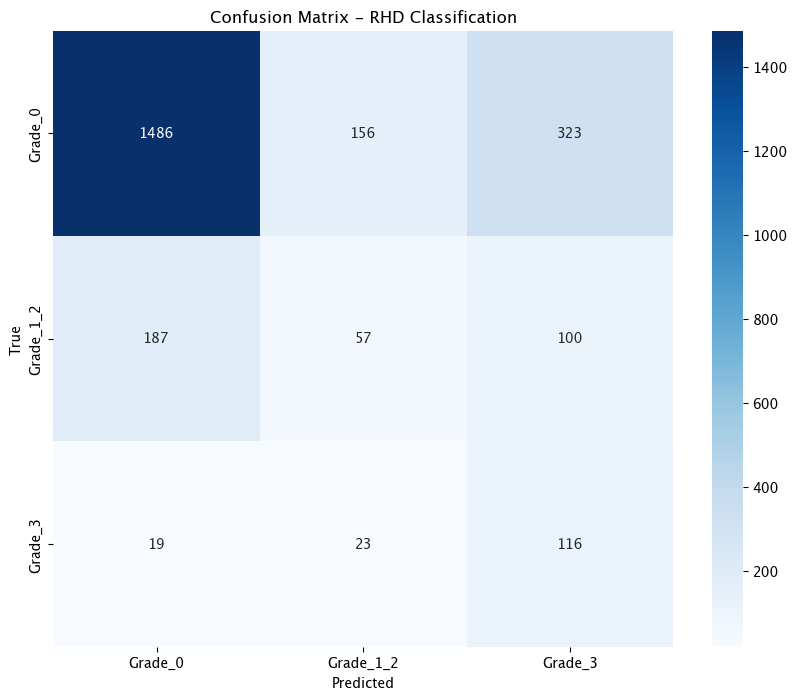


📊 Per-Class Performance Details:

Grade_0:
  Precision: 0.8783
  Recall:    0.7562
  F1-Score:  0.8127
  Support:   0

Grade_1_2:
  Precision: 0.2415
  Recall:    0.1657
  F1-Score:  0.1966
  Support:   0

Grade_3:
  Precision: 0.2152
  Recall:    0.7342
  F1-Score:  0.3329
  Support:   0

📊 Confidence Scores (Prediction Probabilities):
Average confidence across all predictions: 0.533
  Grade_0: 0.539
  Grade_1_2: 0.503
  Grade_3: 0.528


NameError: name 'json' is not defined

In [4]:
# ============================================================================
# EVALUATION - FIXED (No custom loss function conflicts)
# ============================================================================

print("\n📊 EVALUATING ON TEST SET")
print("="*60)

# Method 1: Use the model directly but compile with a different loss for evaluation
# (This avoids the custom loss function issue)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=config.FINETUNE_LR),
    loss='sparse_categorical_crossentropy',  # Simple loss for evaluation
    metrics=['accuracy']
)

# Now evaluate
test_loss, test_acc = model.evaluate(test_ds_final, verbose=1)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Method 2: If you need the focal loss for training later, reload the best saved model
# from the saved best_finetuned_model.keras with custom objects.
# Uncomment below if you want to reload:
# from tensorflow.keras.models import load_model
# 
# # Define focal_loss function (must be defined before loading)
# def focal_loss(gamma=2., alpha=0.25):
#     def focal_loss_fixed(y_true, y_pred):
#         y_true = tf.cast(y_true, tf.int32)
#         y_true_one_hot = tf.one_hot(y_true, depth=num_classes)
#         epsilon = tf.keras.backend.epsilon()
#         y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
#         cross_entropy = -y_true_one_hot * tf.math.log(y_pred)
#         weight = tf.pow(1. - y_pred, gamma)
#         focal = alpha * weight * cross_entropy
#         return tf.reduce_sum(focal, axis=1)
#     return focal_loss_fixed
# 
# # Load the best model with custom objects
# best_model_path = os.path.join(config.OUTPUT_PATH, 'models', 'best_finetuned_model.keras')
# model = load_model(best_model_path, custom_objects={'focal_loss_fixed': focal_loss})
# test_loss, test_acc = model.evaluate(test_ds_final, verbose=1)

# ============================================================================
# PREDICTIONS AND CLASSIFICATION REPORT
# ============================================================================

print("\n📋 Generating predictions...")
y_true = []
y_pred = []
y_pred_probs = []

for images, labels in test_ds_final:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
    y_pred_probs.extend(preds)

# Classification Report
print("\n📋 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - RHD Classification')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# ============================================================================
# PER-CLASS PERFORMANCE DETAILS
# ============================================================================

print("\n📊 Per-Class Performance Details:")
for i, class_name in enumerate(class_names):
    # True positives for this class
    tp = cm[i, i]
    # False positives
    fp = np.sum(cm[:, i]) - tp
    # False negatives
    fn = np.sum(cm[i, :]) - tp
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"\n{class_name}:")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  Support:   {np.sum(y_true == i)}")

# ============================================================================
# CONFIDENCE SCORES (Optional)
# ============================================================================

print("\n📊 Confidence Scores (Prediction Probabilities):")
y_pred_probs = np.array(y_pred_probs)
avg_confidence = np.mean(np.max(y_pred_probs, axis=1))
print(f"Average confidence across all predictions: {avg_confidence:.3f}")

# Confidence by class
for i, class_name in enumerate(class_names):
    mask = np.array(y_true) == i
    if np.sum(mask) > 0:
        class_conf = np.mean(np.max(y_pred_probs[mask], axis=1))
        print(f"  {class_name}: {class_conf:.3f}")

# ============================================================================
# SAVE RESULTS
# ============================================================================

results = {
    'test_accuracy': float(test_acc),
    'test_loss': float(test_loss),
    'classification_report': classification_report(y_true, y_pred, target_names=class_names, output_dict=True),
    'confusion_matrix': cm.tolist(),
    'config': vars(config)
}

with open(os.path.join(config.OUTPUT_PATH, 'logs', 'experiment_results.json'), 'w') as f:
    json.dump(results, f, indent=2)

print(f"\n✅ Results saved to: {os.path.join(config.OUTPUT_PATH, 'logs', 'experiment_results.json')}")